In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa #Used in audio processing
import librosa.display 
from glob import glob #List out all files in a directory
import IPython.display as ipd
from scipy.fftpack import dct
import os
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [2]:
scream_audio_files = glob('/kaggle/input/audio-dataset-of-scream-and-non-scream/Converted_Separately/scream/*.wav')
non_scream_audio_files = glob('/kaggle/input/audio-dataset-of-scream-and-non-scream/Converted_Separately/non_scream/*.wav')

# Play audio files
print("Scream based audio example file:")
display(ipd.Audio(scream_audio_files[0]))

print("Non-Scream based audio example file:")
display(ipd.Audio(non_scream_audio_files[0]))

Scream based audio example file:


Non-Scream based audio example file:


In [3]:
# y: Raw data
# sr: Sample rate
y1 , sr1 = librosa.load(scream_audio_files[0])
print("Scream audio")
print(f'y1: {y1[:10]}')
print(f'y1: {y1.shape}')
print(f'sr1: {sr1}\n')

y2 , sr2 = librosa.load(non_scream_audio_files[0])
print("Non-scream audio")
print(f'y2: {y2[:10]}')
print(f'y2: {y2.shape}')
print(f'sr2: {sr2}')

Scream audio
y1: [-2.2794826e-10 -4.2252105e-12 -2.0941600e-10  1.3749933e-10
 -1.5653860e-10 -4.7886206e-10 -9.7876263e-10 -1.2237013e-09
 -9.6503205e-10 -1.5045705e-09]
y1: (128067,)
sr1: 22050

Non-scream audio
y2: [ 2.7478384e-09  2.2753071e-08  5.0943711e-09  3.2500487e-09
 -5.8546062e-10 -1.7511622e-08 -1.2032624e-08  1.1282120e-08
 -1.3849863e-08 -1.1703053e-08]
y2: (41212,)
sr2: 22050


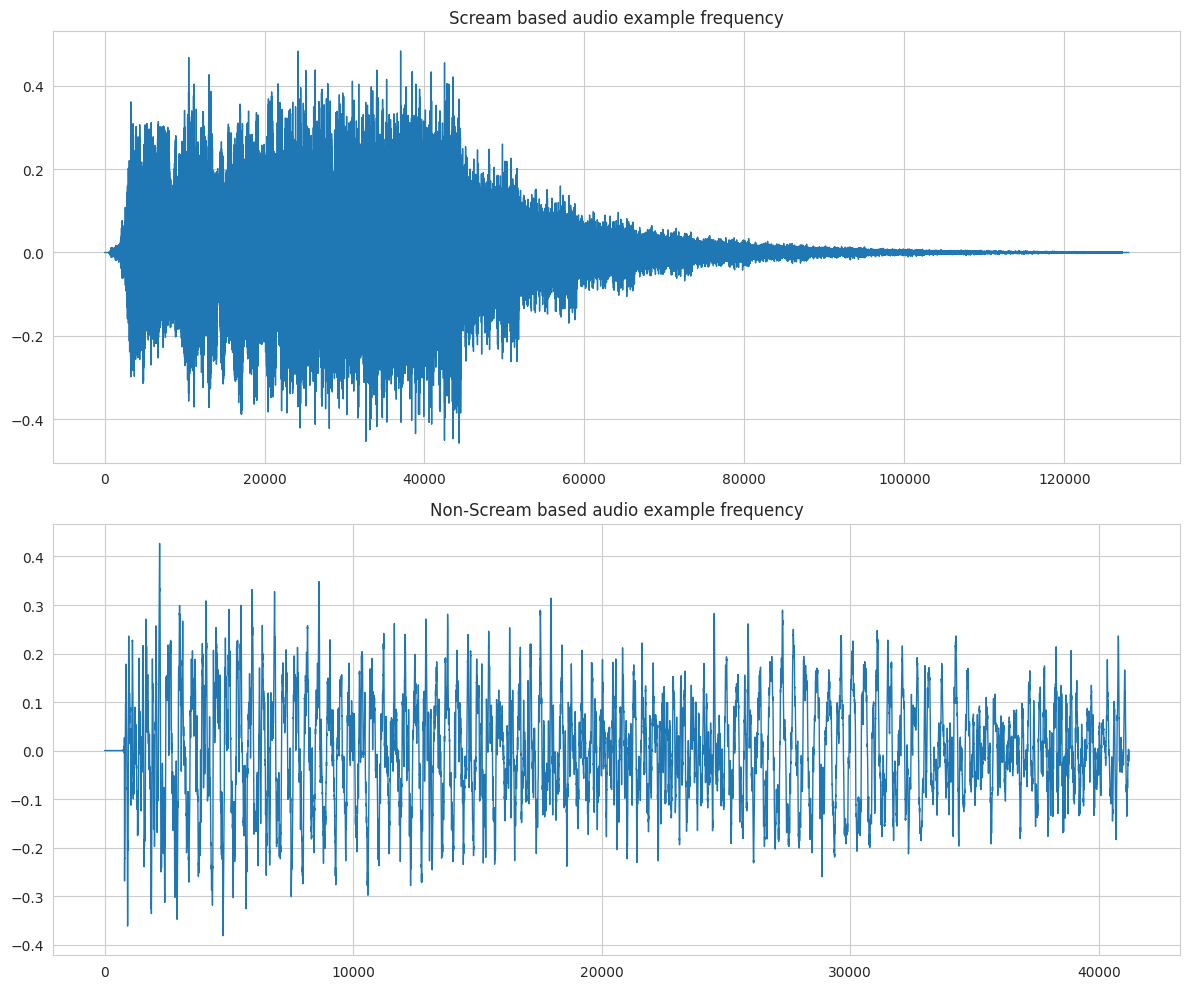

In [4]:
#Frequency graph
sns.set_style("whitegrid")
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
pd.Series(y1).plot(lw=1, title="Scream based audio example frequency")

plt.subplot(2, 1, 2)
pd.Series(y2).plot(lw=1, title="Non-Scream based audio example frequency")

plt.tight_layout()
plt.show()

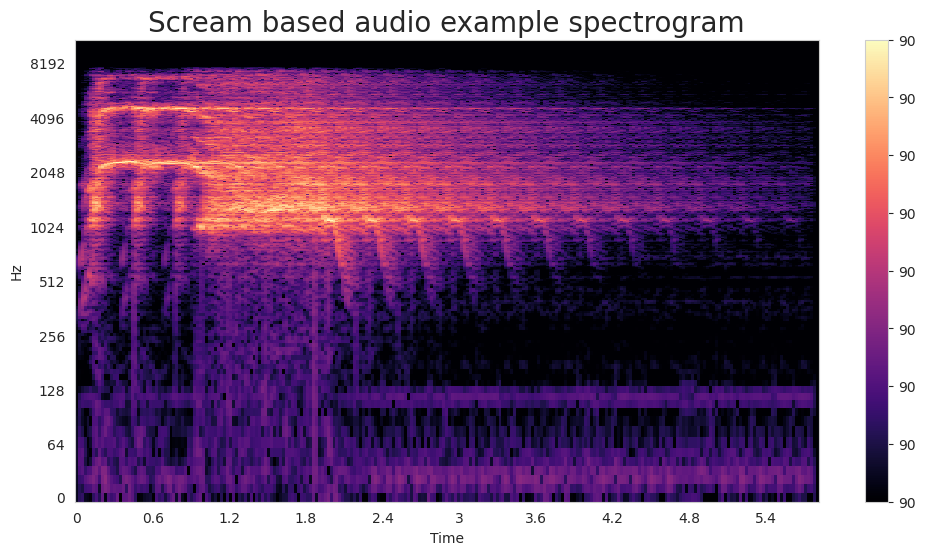

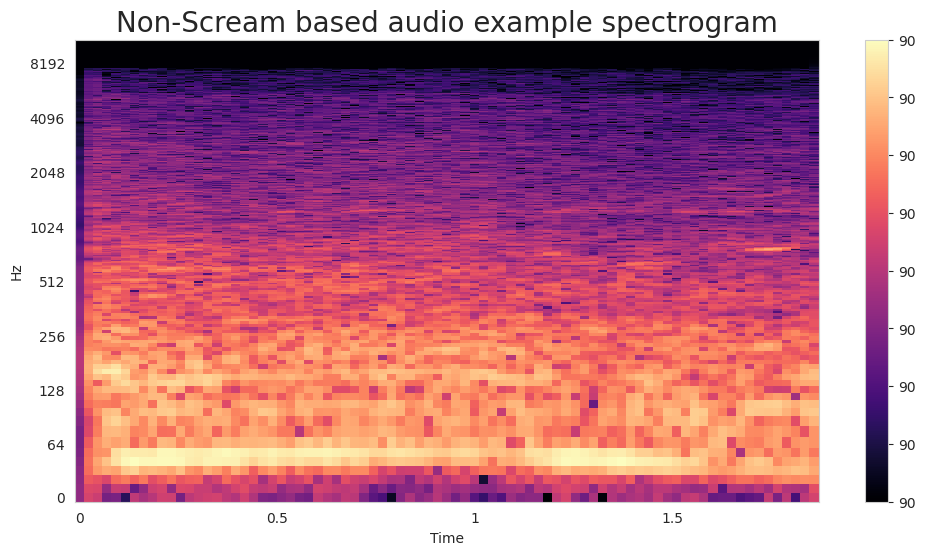

In [5]:
D1=librosa.stft(y1) #Short-Time Fourier Transform (STFT)
S_db1=librosa.amplitude_to_db(np.abs(D1),ref=np.max)
fig1,ax1=plt.subplots(figsize=(12,6))
img=librosa.display.specshow(S_db1,x_axis="time",y_axis="log",ax=ax1)
ax1.set_title("Scream based audio example spectrogram", fontsize=20)
fig1.colorbar(img,ax=ax1,format=f'{90}')
plt.show()

D2=librosa.stft(y2) 
S_db2=librosa.amplitude_to_db(np.abs(D2),ref=np.max)
fig2,ax2=plt.subplots(figsize=(12,6))
img=librosa.display.specshow(S_db2,x_axis="time",y_axis="log",ax=ax2)
ax2.set_title("Non-Scream based audio example spectrogram", fontsize=20)
fig2.colorbar(img,ax=ax2,format=f'{90}')
plt.show()

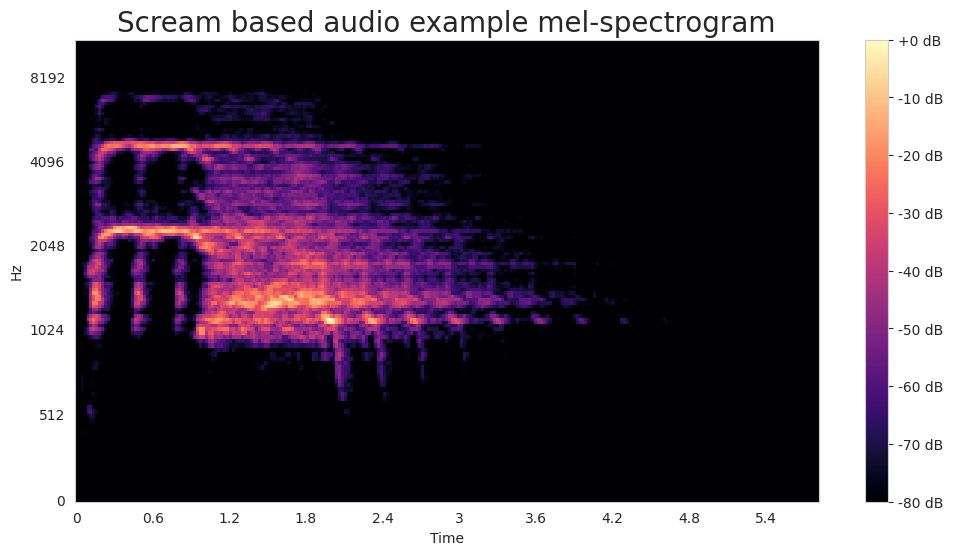

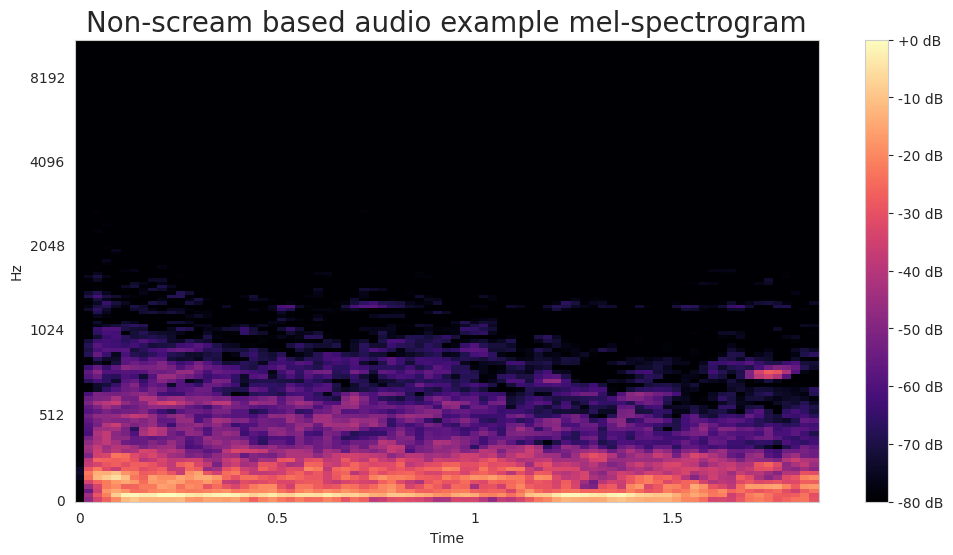

In [6]:
# Mel-Spectrogram
S1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128)
S_db_mel1 = librosa.amplitude_to_db(S1, ref=np.max)

fig_mel1, ax_mel1 = plt.subplots(figsize=(12, 6))
img = librosa.display.specshow(S_db_mel1, x_axis="time", y_axis="mel", sr=sr1, ax=ax_mel1)
ax_mel1.set_title("Scream based audio example mel-spectrogram", fontsize=20)
fig_mel1.colorbar(img, ax=ax_mel1, format='%+2.0f dB')
plt.show()

S2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128)
S_db_mel2 = librosa.amplitude_to_db(S2, ref=np.max)

fig_mel2, ax_mel2 = plt.subplots(figsize=(12, 6))
img = librosa.display.specshow(S_db_mel2, x_axis="time", y_axis="mel", sr=sr2, ax=ax_mel2)
ax_mel2.set_title("Non-scream based audio example mel-spectrogram", fontsize=20)
fig_mel2.colorbar(img, ax=ax_mel2, format='%+2.0f dB')
plt.show()

In [7]:
#MFCC 
mfcc1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
mfcc2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)

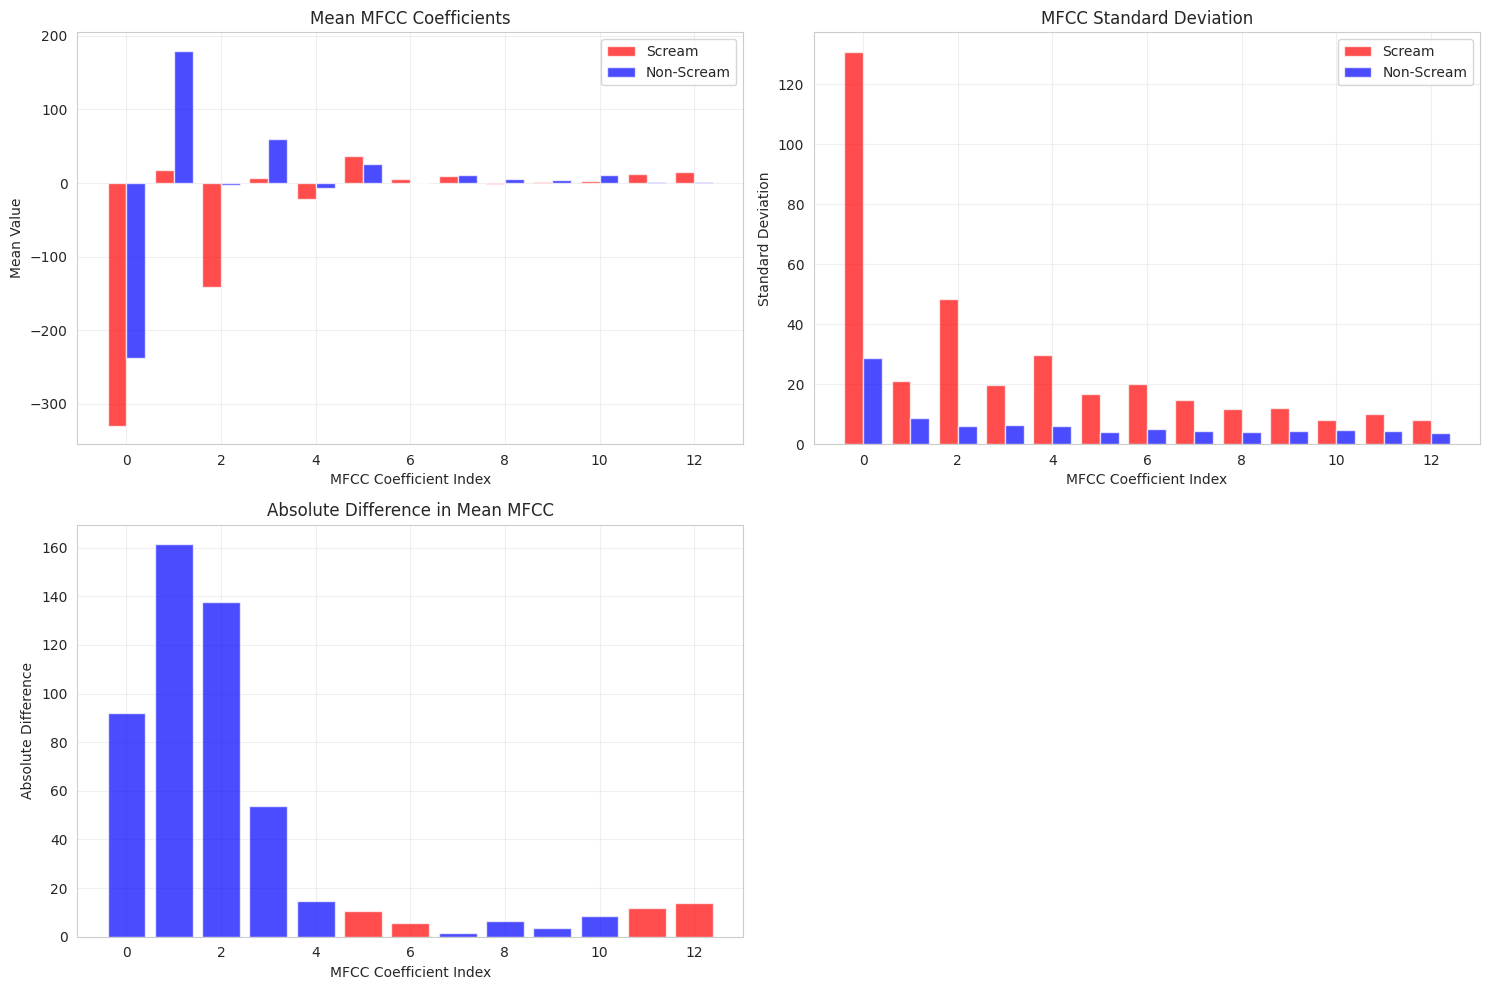

In [8]:
#Statistical analysis of MFCC
mfcc1_mean = np.mean(mfcc1, axis=1)
mfcc1_std = np.std(mfcc1, axis=1)
mfcc2_mean = np.mean(mfcc2, axis=1)
mfcc2_std = np.std(mfcc2, axis=1)

# Create subplots
fig_stats, axes = plt.subplots(2, 2, figsize=(15, 10))

x = np.arange(13)

# Mean comparison
x = np.arange(13)
axes[0,0].bar(x - 0.2, mfcc1_mean, 0.4, label='Scream', alpha=0.7, color='red')
axes[0,0].bar(x + 0.2, mfcc2_mean, 0.4, label='Non-Scream', alpha=0.7, color='blue')
axes[0,0].set_title('Mean MFCC Coefficients')
axes[0,0].set_xlabel('MFCC Coefficient Index')
axes[0,0].set_ylabel('Mean Value')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Standard deviation comparison
axes[0,1].bar(x - 0.2, mfcc1_std, 0.4, label='Scream', alpha=0.7, color='red')
axes[0,1].bar(x + 0.2, mfcc2_std, 0.4, label='Non-Scream', alpha=0.7, color='blue')
axes[0,1].set_title('MFCC Standard Deviation')
axes[0,1].set_xlabel('MFCC Coefficient Index')
axes[0,1].set_ylabel('Standard Deviation')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Absolute difference
diff = np.abs(mfcc1_mean - mfcc2_mean)
colors = ['red' if mfcc1_mean[i] > mfcc2_mean[i] else 'blue' for i in range(13)]
axes[1,0].bar(x, diff, color=colors, alpha=0.7)
axes[1,0].set_title('Absolute Difference in Mean MFCC')
axes[1,0].set_xlabel('MFCC Coefficient Index')
axes[1,0].set_ylabel('Absolute Difference')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
#Creating a CSV sheet containing all MFCC valeus extracted from the rest of the files.
def extract_features(file_path, label, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    # Create feature names
    feature_names = [f"mfcc{i+1}_mean" for i in range(n_mfcc)] + [f"mfcc{i+1}_std" for i in range(n_mfcc)]
    features = np.hstack([mfcc_mean, mfcc_std])
    
    return dict(zip(feature_names, features)) | {
        "label": label,
        "file": os.path.basename(file_path)
    }

# Build dataset
data = []

for file in scream_audio_files:
    data.append(extract_features(file, "scream"))

for file in non_scream_audio_files:
    data.append(extract_features(file, "non_scream"))

# Convert to DataFrame
df = pd.DataFrame(data)

print("Dataset shape:", df.shape)
print(df.head())
print(df.tail())
      

Dataset shape: (3128, 28)
   mfcc1_mean  mfcc2_mean  mfcc3_mean  mfcc4_mean  mfcc5_mean  mfcc6_mean  \
0 -294.653564  -35.390968 -109.907341   -2.271657    2.690651   30.328678   
1 -398.336304   -6.149135  -57.125317   10.146070   19.625772   18.247858   
2 -404.223480   51.673298  -18.334959  -12.625723  -20.372261   -3.486861   
3 -290.313690   54.070679  -59.562447   17.074772   -2.810919   32.133755   
4 -129.994156  142.416946  -64.631134  -31.184484   -2.717144    2.385000   

   mfcc7_mean  mfcc8_mean  mfcc9_mean  mfcc10_mean  ...  mfcc6_std  mfcc7_std  \
0    2.363413    5.940885   -1.170767     2.768470  ...  14.056701  12.749208   
1   -1.447362   15.531037   -2.835519    -1.611299  ...  23.584949  15.978212   
2   -4.054679   -8.123486  -11.504803     2.417782  ...  12.371582   9.425100   
3   30.685987   17.805187   -3.617066   -15.912820  ...  19.659149  11.714629   
4    6.450145  -15.797209  -16.489084     9.735652  ...   6.771634   6.213570   

   mfcc8_std  mfcc9_std 

In [10]:
#Creating a CSV file to store the database
df.to_csv("audio_features.csv", index=False)